# Uplift Modelling for Targeted Email Marketing Campaigns

**Main question:** Which customers should receive a marketing campaign because the campaign actually changes their behaviour?

A normal model predicts who is likely to buy. An uplift model predicts who is more likely to buy **because of the campaign**.


# Step 1: Import libraries

In [1]:

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score


## Step 2: Set project folders

Put your CSV file inside `data/raw/`.

In [2]:
PROJECT_ROOT = Path(r"E:\uplift_modelling_email_marketing_project")

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
SUMMARY_PATH = PROJECT_ROOT / "outputs" / "business_summary.md"

for folder in [RAW_DIR, PROCESSED_DIR, FIG_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", RAW_DIR)
print("Raw folder exists:", RAW_DIR.exists())


Project root: E:\uplift_modelling_email_marketing_project
Raw data folder: E:\uplift_modelling_email_marketing_project\data\raw
Raw folder exists: True


## Step 3: Load the dataset

Download the Hillstrom / MineThatData email dataset and put the CSV file inside `data/raw/`.

In [3]:
csv_files = list(RAW_DIR.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError("No CSV file found in data/raw. Put the Hillstrom CSV inside data/raw.")

csv_path = csv_files[0]
print("Using dataset:", csv_path)

df = pd.read_csv(csv_path)
df.head()


Using dataset: E:\uplift_modelling_email_marketing_project\data\raw\Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


# Step 4: Clean Column names

In [4]:
df = df.copy()
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

print(df.shape)
df.head()


(64000, 12)


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


## Step 5: Check columns and missing values

In [5]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nData types:")
print(df.dtypes)


Columns:
['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'segment', 'visit', 'conversion', 'spend']

Missing values:
recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
segment            0
visit              0
conversion         0
spend              0
dtype: int64

Data types:
recency              int64
history_segment        str
history            float64
mens                 int64
womens               int64
zip_code               str
newbie               int64
channel                str
segment                str
visit                int64
conversion           int64
spend              float64
dtype: object


## Step 6: Create treatment and outcome variables

- `treatment = 1`: customer received Mens or Womens email
- `treatment = 0`: customer received No E-Mail
- `outcome = conversion`

In [6]:
df["segment"] = df["segment"].astype(str).str.strip()
df["treatment"] = np.where(df["segment"].str.lower().eq("no e-mail"), 0, 1)
df["outcome"] = df["conversion"].astype(int)
df["customer_id"] = np.arange(1, len(df) + 1)

df[["customer_id", "segment", "treatment", "conversion", "outcome"]].head()


,customer_id,segment,treatment,conversion,outcome
0,1,Womens E-Mail,1,0,0
1,2,No E-Mail,0,0,0
2,3,Womens E-Mail,1,0,0
3,4,Mens E-Mail,1,0,0
4,5,Womens E-Mail,1,0,0


1. Clean campaign group names
2. Mark email customers as treatment = 1
3. Mark no-email customers as treatment = 0
4. Use conversion as the outcome
5. Add customer IDs
6. Display the result

## Step 7: Treatment group counts

In [7]:
treatment_counts=df['segment'].value_counts().reset_index()
treatment_counts.columns=['segment','count']
treatment_counts.to_csv(TABLE_DIR / "treatment_counts.csv", index=False)
treatment_counts


,segment,count
0,Womens E-Mail,21387
1,Mens E-Mail,21307
2,No E-Mail,21306


## Step 8: Outcome summary by segment

In [8]:
outcome_summary=(df.groupby('segment')
                 .agg(customers=('customer_id','count'),
                      visit_rate=('visit','mean'),
                      conversion_rate=('conversion','mean'),
                      avg_spend=('spend','mean')).reset_index())
outcome_summary.to_csv(TABLE_DIR / "outcome_summary_by_segment.csv", index=False)
outcome_summary


,segment,customers,visit_rate,conversion_rate,avg_spend
0,Mens E-Mail,21307,0.182757,0.012531,1.422617
1,No E-Mail,21306,0.106167,0.005726,0.652789
2,Womens E-Mail,21387,0.151400,0.008837,1.077202


## Step 9: Plot conversion rate by segment

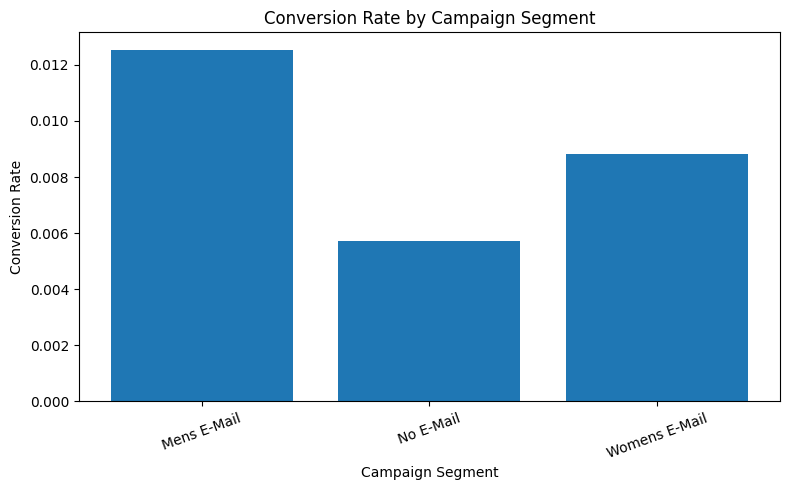

In [9]:
plt.figure(figsize=(8, 5))
plt.bar(outcome_summary["segment"], outcome_summary["conversion_rate"])
plt.title("Conversion Rate by Campaign Segment")
plt.xlabel("Campaign Segment")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "conversion_rate_by_segment.png", dpi=150)
plt.show()


## Step 10: Plot average spend by segment

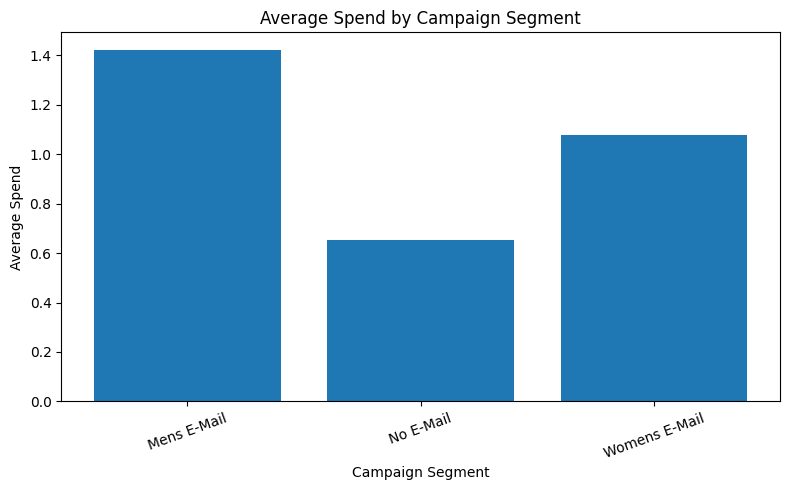

In [10]:
plt.figure(figsize=(8,5))
plt.bar(outcome_summary['segment'],outcome_summary['avg_spend'])
plt.title("Average Spend by Campaign Segment")
plt.xlabel("Campaign Segment")
plt.ylabel("Average Spend")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "average_spend_by_segment.png", dpi=150)
plt.show()


## Step 11: Calculate simple uplift

`uplift = conversion rate of treated group - conversion rate of control group`

In [11]:
treated=df[df['treatment']==1]
control=df[df['treatment']==0]

treated_conversion=treated['outcome'].mean()
control_conversion=control['outcome'].mean()
uplift=treated_conversion - control_conversion
relative_lift=uplift/control_conversion if control_conversion != 0 else np.nan

simple_uplift_summary = pd.DataFrame({
    'metric':['Treated Conversion Rate', 'Control Conversion Rate', 'Uplift', 'Relative Lift'],
    'value': [treated_conversion, control_conversion, uplift, relative_lift]
})
simple_uplift_summary.to_csv(TABLE_DIR/"simple_uplift_summary.csv", index=False)
simple_uplift_summary


,metric,value
0,Treated Conversion Rate,0.010681
1,Control Conversion Rate,0.005726
2,Uplift,0.004955
3,Relative Lift,0.865263


## Step 12: Choose modelling features

We use customer information available before the campaign. We do not use treatment/outcome columns as features.

In [12]:
features = [
    "recency",
    "history_segment",
    "history",
    "mens",
    "womens",
    "zip_code",
    "newbie",
    "channel"
]

X = df[features].copy()
y = df["outcome"].copy()
treatment = df["treatment"].copy()

X.head()


,recency,history_segment,history,mens,womens,zip_code,newbie,channel
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web


## Step 13: Split data into train and test sets

In [13]:
X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X, y, treatment, test_size=0.30, random_state=42, stratify=treatment
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print(t_train.value_counts())
print(t_test.value_counts())


Training rows: 44800
Testing rows: 19200
treatment
1    29886
0    14914
Name: count, dtype: int64
treatment
1    12808
0     6392
Name: count, dtype: int64


## Step 14: Create treated and control training data

For a T-Learner, we train one model on treated customers and one model on control customers.

In [14]:
X_train_treated = X_train[t_train == 1]
y_train_treated = y_train[t_train == 1]

X_train_control = X_train[t_train == 0]
y_train_control = y_train[t_train == 0]

print("Treated training rows:", X_train_treated.shape[0])
print("Control training rows:", X_train_control.shape[0])


Treated training rows: 29886
Control training rows: 14914


## Step 15: Preprocessing pipeline

In [15]:
categorical_cols = X_train.select_dtypes(include=["str"]).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=["str"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)


Categorical columns: ['history_segment', 'zip_code', 'channel']
Numeric columns: ['recency', 'history', 'mens', 'womens', 'newbie']


## Step 16: Train T-Learner models

In [16]:
treated_model=Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200,max_depth=8,min_samples_leaf=50,random_state=42,n_jobs=-1))
])
control_model=Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200,max_depth=8,min_samples_leaf=50,random_state=42,n_jobs=-1))
])
treated_model.fit(X_train_treated,y_train_treated)
control_model.fit(X_train_control,y_train_control)
print ('Models trained successfully.')


Models trained successfully.


## Step 17: Evaluate treated and control models with ROC-AUC

In [17]:
test_treated_mask = t_test == 1
test_control_mask = t_test == 0

treated_pred = treated_model.predict_proba(X_test[test_treated_mask])[:, 1]
control_pred = control_model.predict_proba(X_test[test_control_mask])[:, 1]

treated_auc = roc_auc_score(y_test[test_treated_mask], treated_pred)
control_auc = roc_auc_score(y_test[test_control_mask], control_pred)

model_metrics = pd.DataFrame({
    "metric": ["treated_model_auc", "control_model_auc"],
    "value": [treated_auc, control_auc]
})

model_metrics.to_csv(TABLE_DIR / "model_metrics.csv", index=False)
model_metrics



,metric,value
0,treated_model_auc,0.594065
1,control_model_auc,0.623105


## Step 18: Predict individual customer uplift

`predicted_uplift = P(conversion if treated) - P(conversion if control)`

In [18]:
p_treated = treated_model.predict_proba(X)[:, 1]
p_control = control_model.predict_proba(X)[:, 1]
predicted_uplift = p_treated - p_control

scored = df.copy()
scored["p_conversion_if_treated"] = p_treated
scored["p_conversion_if_control"] = p_control
scored["predicted_uplift"] = predicted_uplift

scored = scored.sort_values("predicted_uplift", ascending=False)
scored.to_csv(PROCESSED_DIR / "customers_scored_by_predicted_uplift.csv", index=False)

scored[["customer_id", "segment", "p_conversion_if_treated", "p_conversion_if_control", "predicted_uplift"]].head(10)


,customer_id,segment,p_conversion_if_treated,p_conversion_if_control,predicted_uplift
55255,55256,Womens E-Mail,0.049208,0.007253,0.041955
6303,6304,Mens E-Mail,0.048958,0.007253,0.041706
21975,21976,No E-Mail,0.048394,0.007253,0.041142
42521,42522,Mens E-Mail,0.045573,0.007209,0.038364
48995,48996,Womens E-Mail,0.045296,0.007347,0.037949
6368,6369,No E-Mail,0.044857,0.007148,0.037708
49999,50000,No E-Mail,0.045712,0.008154,0.037558
18567,18568,Mens E-Mail,0.045397,0.008154,0.037243
24970,24971,No E-Mail,0.045397,0.008154,0.037243
46936,46937,No E-Mail,0.045281,0.008154,0.037127


## Step 19: Create uplift deciles

Decile 1 contains customers with the highest predicted uplift.

In [19]:
scored["decile"] = pd.qcut(
    scored["predicted_uplift"].rank(method="first", ascending=False),
    q=10,
    labels=False
) + 1

decile_summary = (
    scored.groupby("decile")
    .apply(lambda x: pd.Series({
        "customers": len(x),
        "treated_customers": (x["treatment"] == 1).sum(),
        "control_customers": (x["treatment"] == 0).sum(),
        "treated_conversion_rate": x.loc[x["treatment"] == 1, "outcome"].mean(),
        "control_conversion_rate": x.loc[x["treatment"] == 0, "outcome"].mean(),
        "actual_uplift": (
            x.loc[x["treatment"] == 1, "outcome"].mean()
            - x.loc[x["treatment"] == 0, "outcome"].mean()
        ),
        "avg_predicted_uplift": x["predicted_uplift"].mean()
    }))
    .reset_index()
)

decile_summary.to_csv(TABLE_DIR / "uplift_by_decile.csv", index=False)
decile_summary


,decile,customers,treated_customers,control_customers,treated_conversion_rate,control_conversion_rate,actual_uplift,avg_predicted_uplift
0,1,6400.0,4277.0,2123.0,0.039747,0.002826,0.036921,0.015524
1,2,6400.0,4228.0,2172.0,0.018921,0.002762,0.016159,0.009812
2,3,6400.0,4213.0,2187.0,0.010919,0.002743,0.008175,0.007704
3,4,6400.0,4284.0,2116.0,0.007703,0.000945,0.006758,0.006365
4,5,6400.0,4313.0,2087.0,0.005101,0.001917,0.003184,0.005289
5,6,6400.0,4288.0,2112.0,0.006297,0.004735,0.001562,0.004252
6,7,6400.0,4275.0,2125.0,0.005380,0.003294,0.002086,0.003123
7,8,6400.0,4252.0,2148.0,0.003528,0.003724,-0.000197,0.002009
8,9,6400.0,4319.0,2081.0,0.006251,0.005286,0.000966,0.000393
9,10,6400.0,4245.0,2155.0,0.003062,0.028770,-0.025708,-0.003768


## Step 20: Plot actual uplift by decile

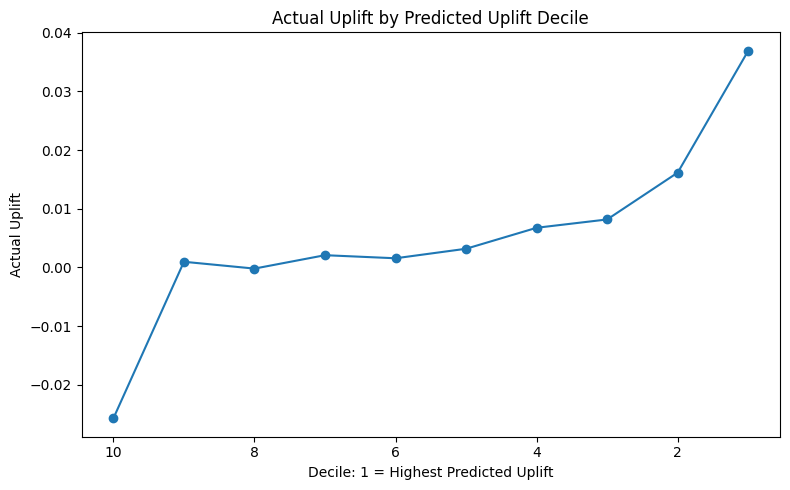

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(decile_summary["decile"], decile_summary["actual_uplift"], marker="o")
plt.title("Actual Uplift by Predicted Uplift Decile")
plt.xlabel("Decile: 1 = Highest Predicted Uplift")
plt.ylabel("Actual Uplift")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "actual_uplift_by_decile.png", dpi=150)
plt.show()


## Step 21: Plot predicted uplift by decile

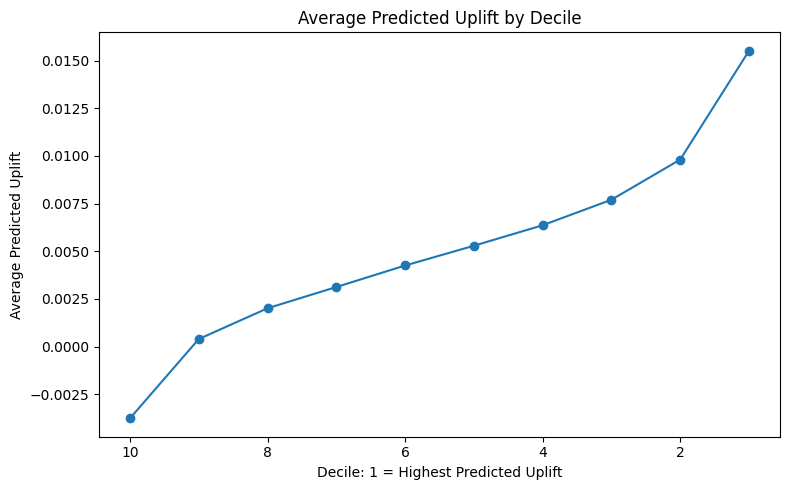

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(decile_summary["decile"], decile_summary["avg_predicted_uplift"], marker="o")
plt.title("Average Predicted Uplift by Decile")
plt.xlabel("Decile: 1 = Highest Predicted Uplift")
plt.ylabel("Average Predicted Uplift")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "predicted_uplift_by_decile.png", dpi=150)
plt.show()


## Step 22: Select top 20% customers to target

In [22]:
top_fraction = 0.20
n_top = int(len(scored) * top_fraction)
top_customers = scored.head(n_top).copy()

selected_cols = [
    "customer_id", "segment", "recency", "history_segment", "history",
    "mens", "womens", "zip_code", "newbie", "channel",
    "p_conversion_if_treated", "p_conversion_if_control", "predicted_uplift"
]

top_customers[selected_cols].to_csv(
    TABLE_DIR / f"top_{int(top_fraction * 100)}pct_customers_to_target.csv", index=False
)

top_customers[selected_cols].head()


,customer_id,segment,recency,history_segment,history,mens,womens,zip_code,newbie,channel,p_conversion_if_treated,p_conversion_if_control,predicted_uplift
55255,55256,Womens E-Mail,1,"7) $1,000 +",1033.92,1,1,Surburban,1,Web,0.049208,0.007253,0.041955
6303,6304,Mens E-Mail,1,"7) $1,000 +",1010.11,1,1,Surburban,1,Web,0.048958,0.007253,0.041706
21975,21976,No E-Mail,1,"7) $1,000 +",1035.14,1,1,Surburban,1,Web,0.048394,0.007253,0.041142
42521,42522,Mens E-Mail,1,"7) $1,000 +",1101.71,1,1,Surburban,1,Web,0.045573,0.007209,0.038364
48995,48996,Womens E-Mail,1,"7) $1,000 +",1085.17,1,1,Surburban,1,Web,0.045296,0.007347,0.037949


## Step 23: Business summary numbers

In [23]:
top_actual_conversion = top_customers["outcome"].mean()
top_avg_predicted_uplift = top_customers["predicted_uplift"].mean()

business_numbers = pd.DataFrame({
    "metric": [
        "total_customers", "customers_targeted_top_20pct",
        "treated_conversion_rate", "control_conversion_rate",
        "absolute_uplift", "relative_lift",
        "treated_model_auc", "control_model_auc",
        "top_20pct_actual_conversion", "top_20pct_avg_predicted_uplift"
    ],
    "value": [
        len(df), len(top_customers), treated_conversion, control_conversion,
        uplift, relative_lift, treated_auc, control_auc,
        top_actual_conversion, top_avg_predicted_uplift
    ]
})

business_numbers


,metric,value
0,total_customers,64000.000000
1,customers_targeted_top_20pct,12800.000000
2,treated_conversion_rate,0.010681
3,control_conversion_rate,0.005726
4,absolute_uplift,0.004955
5,relative_lift,0.865263
6,treated_model_auc,0.594065
7,control_model_auc,0.623105
8,top_20pct_actual_conversion,0.020469
9,top_20pct_avg_predicted_uplift,0.012668
